In [19]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import sys
import torch

sys.path = ["..", *sys.path]

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
# npz_file = np.load(f"/result_data/ad2_tbg_full.npz")
from bgflow import MeanFreeNormalDistribution

npz_file = np.load(f"../old/result_data/Flow-Matching-AD2-amber-weighted-encoding.npz")

latent_np = npz_file["latent_np"]
samples_np = npz_file["samples_np"]
dlogp_np = npz_file["dlogp_np"]
dim = 66
n_particles = 22
prior = MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False)
logp = -prior.energy(torch.from_numpy(latent_np)) - torch.from_numpy(dlogp_np).reshape(-1, 1)
samples = torch.from_numpy(samples_np)
samples = samples / 10 / datamodule.std

In [43]:
sample_file = torch.load(
    "/network/scratch/a/alexander.tong/fast-tbg/logs/train/multiruns/2025-01-26_21-18-11/0/test_samples.pt"
)
samples = sample_file["samples"]
logp = sample_file["log_p"]

/tmp/ipykernel_1975732/1700389774.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_file = torch.load(


In [58]:
import hydra

cfg = {
    "_target_": "src.data.aldp_datamodule.ALDPDataModule",
    "data_dir": "../data/AD2/",
    "batch_size": 512,  # Needs to be divisible by the number of devices (e.g., if in a distributed setup)
    "num_workers": 0,
    "n_particles": 22,
    "n_dimensions": 3,
    "dim": 66,
}
datamodule = hydra.utils.instantiate(cfg)
datamodule.setup()

Using downloaded and verified file: /tmp/A.pdb


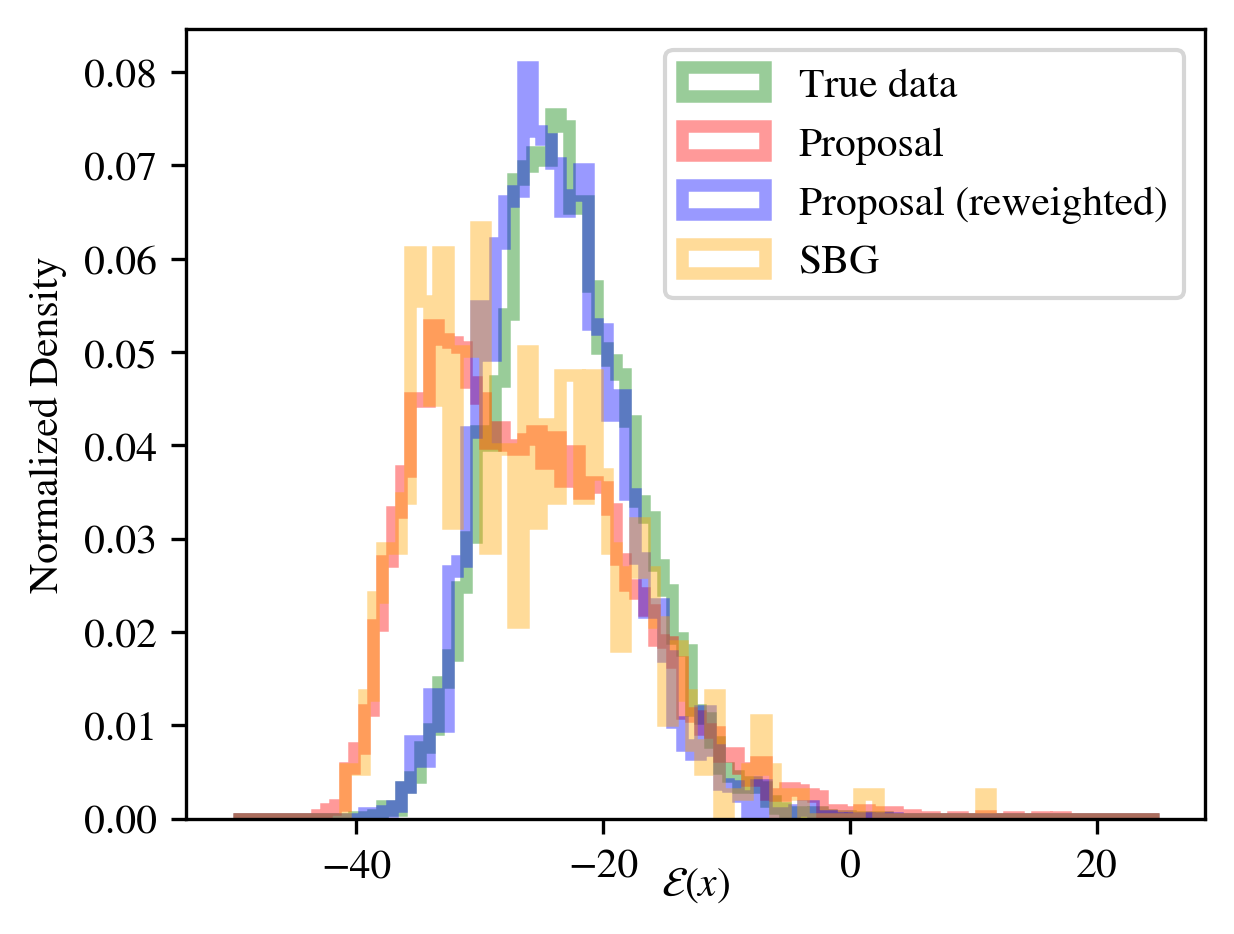

In [59]:
import matplotlib.pyplot as plt

datamodule.plot_nice_samples(
    samples, log_p_samples=logp, samples_jarzynski=samples[:500], min_energy=-50, max_energy=25
)
plt.savefig("density.png", dpi=300)